####  Title: Convolutional neural network (CNN) (Any One from the following)
1. Use any dataset of plant disease and design a plant disease detection system using CNN.
2.  **Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.**

- **Note:** I have selected the 2nd Option: Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

#### Name: Sankalp S. Indish

#### Roll No.: BEB75

#### Step 1: Import Libraries and Load Data
We use the fashion_mnist dataset available directly in Keras.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Load the dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Define class names for better visualization later
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


#### Step 2: Data Preprocessing
CNNs require the input data to have a specific shape: (Batch Size, Height, Width, Channels). Since these are grayscale images, the channel is 1. We also normalize pixel values to be between 0 and 1.

In [3]:
# Reshape the data to include the channel dimension (28, 28, 1)
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

# Normalize pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"New shape after reshaping: {X_train.shape}")

New shape after reshaping: (60000, 28, 28, 1)


#### Step 3: Build the CNN Model
A standard CNN architecture consists of:

1. Conv2D: Extracts features (edges, textures) using filters.

2. MaxPooling2D: Reduces the spatial dimensions (downsamples) to reduce computation.

3. Flatten: Converts the 2D matrix into a 1D vector for the dense layers.

4. Dense (Output): 10 neurons (one for each clothing category) with Softmax activation (probability distribution).

In [4]:
model = Sequential()

# 1. Convolutional Layer
# 32 filters of size 3x3, ReLU activation
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# 2. Max Pooling Layer
# Reduces the matrix size by taking the max value in a 2x2 window
model.add(MaxPooling2D((2, 2)))

# 3. Flatten Layer
model.add(Flatten())

# 4. Dense Hidden Layer
model.add(Dense(128, activation='relu'))

# 5. Output Layer
# 10 neurons for the 10 classes, Softmax for probability
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

#### Step 4: Train the Model
We train for 10 epochs. The validation_split helps us check if the model is overfitting.

In [5]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7930 - loss: 0.5992 - val_accuracy: 0.8868 - val_loss: 0.3205
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8947 - loss: 0.2936 - val_accuracy: 0.9013 - val_loss: 0.2785
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9117 - loss: 0.2399 - val_accuracy: 0.8978 - val_loss: 0.2858
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9242 - loss: 0.2086 - val_accuracy: 0.9071 - val_loss: 0.2538
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9341 - loss: 0.1825 - val_accuracy: 0.9059 - val_loss: 0.2614
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9395 - loss: 0.1655 - val_accuracy: 0.9131 - val_loss: 0.2524
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9480 - loss: 0.1414 - val_accuracy: 0.9130 - val_loss: 0.2502
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9567 - loss: 0.1207 - val_accuracy: 0.

#### Step 5: Evaluate the Model
Check the accuracy on the test dataset.

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy: {test_acc*100:.2f}%')

313/313 - 1s - 4ms/step - accuracy: 0.9064 - loss: 0.3102

Test accuracy: 90.64%


#### Step 6: Visualization (Prediction)
Let's visually check if the model is predicting the correct clothing items.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


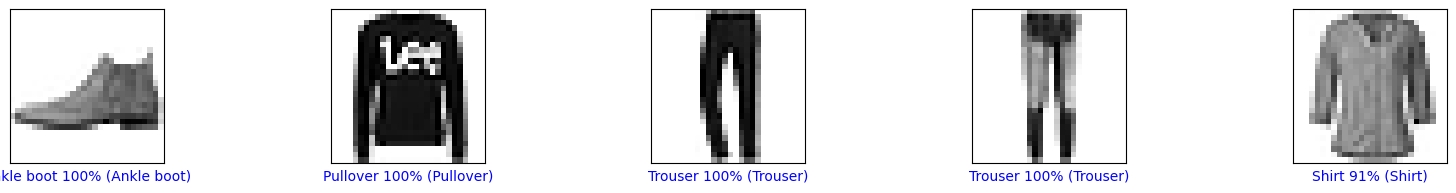

In [7]:
# Get predictions for the test set
predictions = model.predict(X_test)

# Function to plot the image and the prediction
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img.reshape(28, 28), cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

# Plot the first 5 test images, their predicted label, and the true label
num_rows = 1
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, num_cols, i+1)
  plot_image(i, predictions, y_test, X_test)
plt.show()

1. Why use a CNN instead of a standard ANN (Dense Network)?

**Ans.** CNNs can capture spatial hierarchies (patterns like edges and shapes) and are translation invariant (it recognizes a shirt regardless of where it is in the image). ANNs lose this spatial information when you flatten the image immediately.

2. What does the Conv2D layer do?

**Ans.** It applies filters (kernels) to the input image to create "feature maps" that highlight specific features like vertical lines or curves.

3. What is the purpose of MaxPooling2D?

**Ans.** It reduces the dimensionality of the feature maps, making the computation faster and reducing the risk of overfitting by keeping only the most important features.

4. Why softmax in the output layer?

**Ans.** Because this is a multi-class classification problem (10 classes). Softmax converts the raw output scores into probabilities that sum up to 1.

5. What is sparse_categorical_crossentropy?

**Ans.** It is the loss function used when your classes are integers (0, 1, 2...) rather than one-hot encoded vectors.